# NOTAS

Probar hacer subclases para svm y qsvm para que cada una pueda tener su dataset con su propia técnica

In [102]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA

from pandas import read_csv, DataFrame, concat

from numpy import arange, full, nan, size, shape, pi, identity, array

from seaborn import heatmap

import os

from varname import nameof

import matplotlib.pyplot as plt

from qiskit.circuit.library import z_feature_map, unitary_overlap, zz_feature_map
from qiskit.primitives import StatevectorSampler

# --- config ---

DATA_PATH = os.path.join('..', 'data', "water_potability.csv")
RANDOM_SEED = 42


NUM_MUESTRAS_ENTRENAMIENTO = 8 * arange(start = 1, stop = 33, dtype=int)
PCA_DIMENTIONS = [2, 3, 4, 5, 6, 7, 8]
FEATURE_MAPS = [z_feature_map, zz_feature_map]
USAR_MATRICES_PRECOMPUTADAS = True
NUM_SHOTS = 1000

[  8  16  24  32  40  48  56  64  72  80  88  96 104 112 120 128 136 144
 152 160 168 176 184 192 200 208 216 224 232 240 248 256]


In [90]:
class qsvm:
    
    # --- data ---

    x = 0
    y = 0

    x_train = 0
    x_test = 0
    
    y_train = 0
    y_test = 0

    x_train_scaled = 0
    x_test_scaled = 0
    
    # --- qsvm

    qsvm = SVC( kernel = 'precomputed') 
    q_kernel = {}
    q_x_test = {}

    
    def getData(self, num_muestras):
        
        data = read_csv(DATA_PATH)
            
        data = data.dropna() # hay que limpiar los NaN, si no el normalizar no tiene sentido
        
        data = data.sample(frac=1,\
                           random_state=RANDOM_SEED)
        
        potable_data = data.loc[data['Potability']==1]
        
        unpotable_data = data.loc[data['Potability']==0]
        
        muestras = int((num_muestras/.8)/2)
        
        data = concat([potable_data.iloc[0:muestras], \
                       unpotable_data.iloc[0:muestras]])
        
        
        data = data.sample(frac = 1, \
                           random_state=RANDOM_SEED)
        
        '''
        
        Hay que ver si se ponen nuevas features
        
        '''
        
        '''
        El documento dice
        
        Imputar valores faltantes (pH: 491 NaN; Sulfato: 781 NaN; Trihalometanos: 162 NaN) por mediana por clase.
        
        Pero no sé si hay que hacer caso a eso xd
        
        '''
        
        potability = data["Potability"]
        
        data = data.drop("Potability", axis = 1) # quitar potabilidad
   
        self.x = data
        self.y = potability

    def proccess_data(self, dim):
        
        data_train, data_test, potability_train, potability_test = \
        train_test_split(self.x, self.y, test_size=.2, random_state=RANDOM_SEED)
        
        self.x_train = data_train
        self.x_test = data_test
        
        scaler = StandardScaler()
        
        data_train_scaled = scaler.fit_transform(data_train)
        data_test_scaled = scaler.transform(data_test)
        
        pca = PCA(n_components = dim, random_state = RANDOM_SEED)
        
        data_train_scaled = pca.fit_transform(data_train_scaled)
        
        data_test_scaled = pca.transform(data_test_scaled)

        self.x_train_scaled = data_train_scaled
        self.x_test_scaled = data_test_scaled
        
        self.y_train = potability_train 
        self.y_test = potability_test


    def test(self):

        x = self.q_x_test
        y = self.y_test
        
        svm = self.qsvm

        y_pred = svm.predict(x)
        
        print(f'Confusion matrix: \n {confusion_matrix(y, y_pred)}\n')
        print(f'Accuracy = {accuracy_score(y, y_pred):.2f}')
        print(f'Clasification report: \n {classification_report(y, \
        y_pred, target_names=['Non-Potable' , 'Potable'])}')        

        print(f'Real y = {list(y)}')
        print(f'Prediction = {y_pred}')
        

    def generar_qsmv(self, fm_function):

        # --- kernel matrix ---

        x_train = self.x_train_scaled

        y_train = self.y_train
        
        
        fm = fm_function(feature_dimension = x_train.shape[1],\
                  #reps=2
                  )
        
        train_size = x_train.shape[0]
        
        kernel_matrix = identity(train_size)
        
        '''
        
        Esto es llenar la matriz de kernel con las mediciones del producto interno para ver qué tanto comparten 2 datos
        
        Se tiene una diagonal de 1's puesto que el producto interno consigo mismo es 1
        
        Esta forma ese más efectiva que hacer el cálculo completo, por el gran tamaño de la matriz
        
        '''
        
        sampler = StatevectorSampler(seed = RANDOM_SEED)
        num_shots = NUM_SHOTS
        
        for x1 in range(0, train_size):
            for x2 in range(x1 + 1, train_size):
                unitary1 = fm.assign_parameters(x_train[x1])
                unitary2 = fm.assign_parameters(x_train[x2])
        
                # Create the overlap circuit
                overlap_circ = unitary_overlap(unitary1, unitary2)
                overlap_circ.measure_all()
        
                # These lines run the qiskit sampler primitive.
                counts = (
                    sampler.run([overlap_circ], shots=num_shots)
                    .result()[0]
                    .data.meas.get_int_counts()
                )
        
                # Assign the probability of the 0 state to the kernel matrix, and the transposed element
                # (since this is an inner product)
                kernel_matrix[x1, x2] = counts.get(0, 0.0) / num_shots
                kernel_matrix[x2, x1] = counts.get(0, 0.0) / num_shots
            # Fill in on-diagonal elements with 1, again, since this is an inner-product corresponding to
            # probability (or alter the code to check these entries and verify they yield 1)
            kernel_matrix[x1, x1] = 1

        # --- test matrix ---

        x_test = self.x_test_scaled
            
        test_size = shape(x_test)[0]
        
        '''
        La matriz de prueba tiene forma test x train, ya que me da la relación entre los datos nuevos y los datos utilizados para el entrenamiento
        '''
        
        test_matrix = full((test_size, train_size), nan)
        
        for x1 in range(0, test_size):
            for x2 in range(0, train_size):
                unitary1 = fm.assign_parameters(x_test[x1])
                unitary2 = fm.assign_parameters(x_train[x2])
        
                # Create the overlap circuit
                overlap_circ = unitary_overlap(unitary1, unitary2)
                overlap_circ.measure_all()
        
                # These lines run the qiskit sampler primitive.
                counts = (
                    sampler.run([overlap_circ], shots=num_shots)
                    .result()[0]
                    .data.meas.get_int_counts()
                )
        
                # Assign the probability of the 0 state to the kernel matrix, and the transposed element
                # (since this is an inner product)
                test_matrix[x1, x2] = counts.get(0, 0.0) / num_shots

        qsvm = SVC(kernel='precomputed')

        qsvm.fit(kernel_matrix, y_train)

        self.q_kernel = kernel_matrix

        
        self.q_x_test = test_matrix
        self.qsvm = qsvm


    def guardar(self, name):

        k_path = os.path.join('..', 'data', 'kernel', f'{name}.csv')
        test_path = os.path.join('..', 'data', 'test', f'{name}.csv')
        
        DataFrame(self.q_kernel).to_csv(k_path)
        
        DataFrame(self.q_x_test).to_csv(test_path)


        print(f'Guardando {name}\n')

In [91]:
#class Data():
#    
#    # --- data ---
#
#    x = 0
#    y = 0
#
#    x_train = 0
#    x_test = 0
#
#
#    x_train_scaled = 0
#    x_test_scaled = 0
#    q_x_test_scaled = 0
#    
#    y_train = 0
#    y_test = 0
#
#    # --- svm
#
#    svm = {}
#
#    # --- qsvm
#
#    qsvm = {}
#
#    q_kernel = {}
#
#    
#    def getData(self):
#        
#        data = read_csv(DATA_PATH)
#            
#        data = data.dropna() # hay que limpiar los NaN, si no el normalizar no tiene sentido
#        
#        data = data.sample(frac=1,\
#                           random_state=RANDOM_SEED)
#        
#        potable_data = data.loc[data['Potability']==1]
#        
#        unpotable_data = data.loc[data['Potability']==0]
#        
#        muestras = int((CANTIDAD_MUESTRAS_ENTRENAMIENTO/.8)/2)
#        
#        data = concat([potable_data.iloc[0:muestras], \
#                       unpotable_data.iloc[0:muestras]])
#        
#        
#        data = data.sample(frac = 1, \
#                           random_state=RANDOM_SEED)
#        
#        '''
#        
#        Hay que ver si se ponen nuevas features
#        
#        '''
#        
#        '''
#        El documento dice
#        
#        Imputar valores faltantes (pH: 491 NaN; Sulfato: 781 NaN; Trihalometanos: 162 NaN) por mediana por clase.
#        
#        Pero no sé si hay que hacer caso a eso xd
#        
#        '''
#        
#        potability = data["Potability"]
#        
#        data = data.drop("Potability", axis = 1) # quitar potabilidad
#
#        self.x = data
#        self.y = potability
#
#    def proccess_data(self):
#        
#        data_train, data_test, potability_train, potability_test = \
#        train_test_split(self.x, self.y, test_size=.2, random_state=RANDOM_SEED)
#        
#        #scaler = MinMaxScaler(feature_range=(0, 2 * pi))
#        
#        scaler = StandardScaler()
#        
#        data_train_scaled = scaler.fit_transform(data_train)
#        data_test_scaled = scaler.transform(data_test)
#        
#        pca = PCA(n_components = 2, random_state=RANDOM_SEED)
#        
#        data_train_scaled = pca.fit_transform(data_train_scaled)
#        
#        data_test_scaled = pca.transform(data_test_scaled)
#
#        self.x_train_scaled = data_train_scaled
#        self.x_test_scaled = data_test_scaled
#        self.y_train = potability_train 
#        self.y_test = potability_test
#
#    def generar_smv(self):
#
#        x = self.x_train_scaled
#        y = self.y_train
#
#        scores = ["precision", "recall"]
#        
#        C = [10]
#        
#        gamma = ["scale"]
#        
#        tuned_parameters = [
#            {"kernel": ["rbf"], "gamma": gamma, "C":C}
#        ]
#        
#        def refit_strategy(cv_results):
#        	
#            cv_results_ = DataFrame(cv_results)
#        
#            best_index = cv_results_["mean_test_recall"].idxmax()
#        
#            return best_index
#        
#        grid_search = GridSearchCV(
#            SVC(), tuned_parameters, scoring=scores, refit=refit_strategy, cv=5, n_jobs=-1
#        )
#        
#        grid_search.fit(x, y)
#
#        self.svm = grid_search
#
#    def test(self, tipo):
#
#
#        if tipo == 'c':
#            
#            x = self.x_test_scaled
#            y = self.y_test
#            svm = self.svm
#        else:
#
#            x = self.q_x_test_scaled
#            y = self.y_test
#            svm = self.qsvm
#
#        y_pred = svm.predict(x)
#        
#        print(f'Confusion matrix: \n {confusion_matrix(y, y_pred)}\n')
#        print(f'Accuracy = {accuracy_score(y, y_pred):.2f}')
#        print(f'Clasification report: \n {classification_report(y, \
#        y_pred, target_names=['Non-Potable' , 'Potable'])}')        
#
#        print(f'Real y = {list(y)}')
#        print(f'Prediction = {y_pred}')
#        
#
#
#    def generar_qsmv(self):
#
#        # --- kernel matrix ---
#
#        x_train = self.x_train_scaled
#
#        y_train = self.y_train
#        
#        
#        fm = zz_feature_map(feature_dimension = x_train.shape[1],\
#                  #reps=2
#                  )
#        
#        train_size = x_train.shape[0]
#        
#        kernel_matrix = identity(train_size)
#        
#        '''
#        
#        Esto es llenar la matriz de kernel con las mediciones del producto interno para ver qué tanto comparten 2 datos
#        
#        Se tiene una diagonal de 1's puesto que el producto interno consigo mismo es 1
#        
#        Esta forma ese más efectiva que hacer el cálculo completo, por el gran tamaño de la matriz
#        
#        '''
#        
#        sampler = StatevectorSampler(seed = RANDOM_SEED)
#        num_shots = 100
#        
#        for x1 in range(0, train_size):
#            for x2 in range(x1 + 1, train_size):
#                unitary1 = fm.assign_parameters(x_train[x1])
#                unitary2 = fm.assign_parameters(x_train[x2])
#        
#                # Create the overlap circuit
#                overlap_circ = unitary_overlap(unitary1, unitary2)
#                overlap_circ.measure_all()
#        
#                # These lines run the qiskit sampler primitive.
#                counts = (
#                    sampler.run([overlap_circ], shots=num_shots)
#                    .result()[0]
#                    .data.meas.get_int_counts()
#                )
#        
#                # Assign the probability of the 0 state to the kernel matrix, and the transposed element
#                # (since this is an inner product)
#                kernel_matrix[x1, x2] = counts.get(0, 0.0) / num_shots
#                kernel_matrix[x2, x1] = counts.get(0, 0.0) / num_shots
#            # Fill in on-diagonal elements with 1, again, since this is an inner-product corresponding to
#            # probability (or alter the code to check these entries and verify they yield 1)
#            kernel_matrix[x1, x1] = 1
#
#        # --- test matrix ---
#
#        x_test = self.x_test_scaled
#            
#        test_size = shape(x_test)[0]
#        
#        '''
#        La matriz de prueba tiene forma test x train, ya que me da la relación entre los datos nuevos y los datos utilizados para el entrenamiento
#        '''
#        
#        test_matrix = full((test_size, train_size), nan)
#        
#        for x1 in range(0, test_size):
#            for x2 in range(0, train_size):
#                unitary1 = fm.assign_parameters(x_test[x1])
#                unitary2 = fm.assign_parameters(x_train[x2])
#        
#                # Create the overlap circuit
#                overlap_circ = unitary_overlap(unitary1, unitary2)
#                overlap_circ.measure_all()
#        
#                # These lines run the qiskit sampler primitive.
#                counts = (
#                    sampler.run([overlap_circ], shots=num_shots)
#                    .result()[0]
#                    .data.meas.get_int_counts()
#                )
#        
#                # Assign the probability of the 0 state to the kernel matrix, and the transposed element
#                # (since this is an inner product)
#                test_matrix[x1, x2] = counts.get(0, 0.0) / num_shots
#
#        qsvm = SVC(kernel='precomputed')
#
#        qsvm.fit(kernel_matrix, y_train)
#
#        self.q_kernel = kernel_matrix
#        self.q_x_test_scaled = test_matrix
#        self.qsvm = qsvm

# Data

## Get data

In [92]:
#data = Data()

#data.getData()

## Pre-proccess data

In [93]:
#data.proccess_data()

# SVM

In [94]:
#data.generar_smv()

# Test

In [95]:
#data.test(tipo = 'c')

In [96]:
#results = DataFrame(grid_search.cv_results_)
#
#
#results.to_csv("laMambaNegra.csv")
#
#print(f'Best params: {grid_search.best_params_}')
#
#results[
#[
#"param_C",
#"param_gamma",
#"mean_test_precision",
#"mean_test_recall",
#]
#]

In [97]:
#heatmap(data.corr(), \
#			 annot=True, \
#			 robust=True, \
#			 vmin= -1, \
#			 vmax= 1)

# QSVM

## Quantum Kernel

In [98]:
qsvm = qsvm()

Procesando n_32_dim_2_z_feature_map
Procesamiento con matrices precomputadas listo
Confusion matrix: 
 [[3 0]
 [3 2]]

Accuracy = 0.62
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.50      1.00      0.67         3
     Potable       1.00      0.40      0.57         5

    accuracy                           0.62         8
   macro avg       0.75      0.70      0.62         8
weighted avg       0.81      0.62      0.61         8

Real y = [0, 1, 1, 0, 1, 1, 1, 0]
Prediction = [0 0 0 0 1 1 0 0]


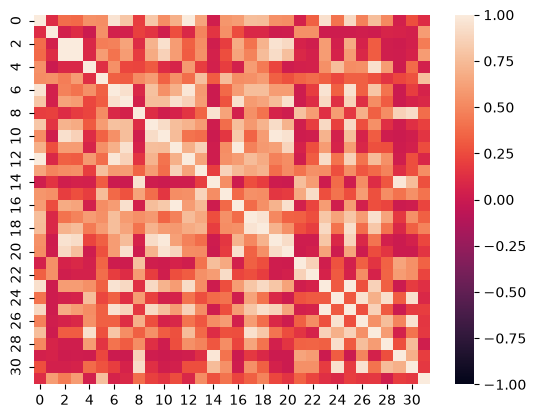

Guardando n_32_dim_2_z_feature_map

Procesando n_40_dim_2_z_feature_map
Procesamiento con matrices precomputadas listo
Confusion matrix: 
 [[3 3]
 [2 2]]

Accuracy = 0.50
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.60      0.50      0.55         6
     Potable       0.40      0.50      0.44         4

    accuracy                           0.50        10
   macro avg       0.50      0.50      0.49        10
weighted avg       0.52      0.50      0.51        10

Real y = [1, 0, 0, 1, 0, 0, 0, 1, 0, 1]
Prediction = [0 0 1 0 1 0 0 1 1 1]


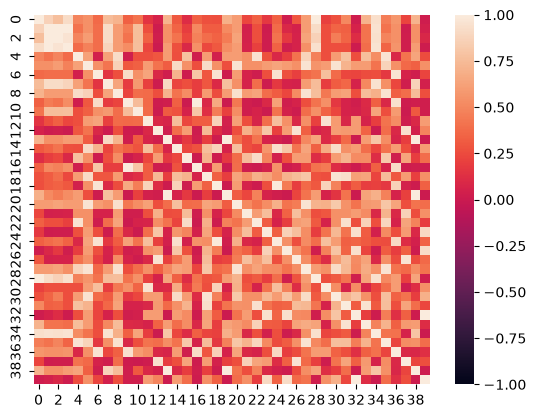

Guardando n_40_dim_2_z_feature_map

Procesando n_48_dim_2_z_feature_map
Procesamiento con matrices precomputadas listo
Confusion matrix: 
 [[4 3]
 [2 3]]

Accuracy = 0.58
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.67      0.57      0.62         7
     Potable       0.50      0.60      0.55         5

    accuracy                           0.58        12
   macro avg       0.58      0.59      0.58        12
weighted avg       0.60      0.58      0.59        12

Real y = [1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1]
Prediction = [1 0 0 0 1 0 0 1 1 1 1 0]


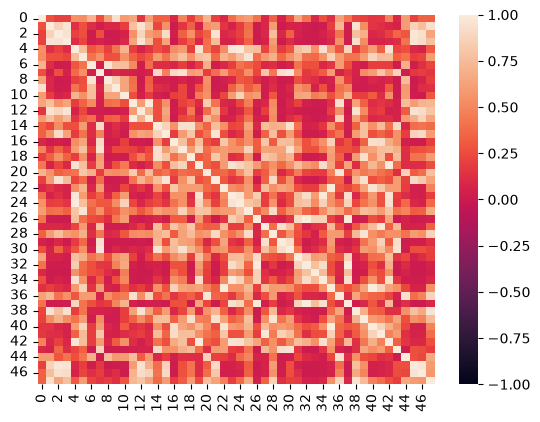

Guardando n_48_dim_2_z_feature_map

Procesando n_56_dim_2_z_feature_map
Procesamiento con matrices precomputadas listo
Confusion matrix: 
 [[6 2]
 [2 4]]

Accuracy = 0.71
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.75      0.75      0.75         8
     Potable       0.67      0.67      0.67         6

    accuracy                           0.71        14
   macro avg       0.71      0.71      0.71        14
weighted avg       0.71      0.71      0.71        14

Real y = [0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1]
Prediction = [0 1 0 0 0 0 0 1 1 0 1 1 0 1]


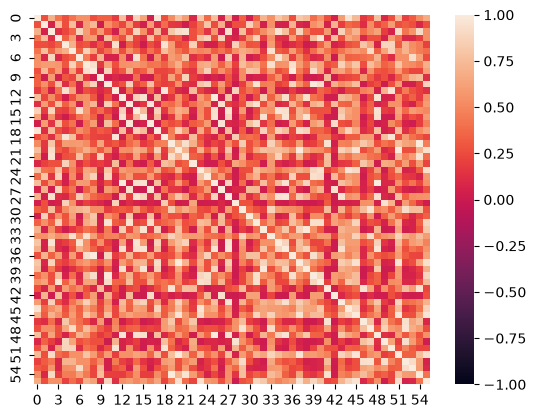

Guardando n_56_dim_2_z_feature_map

Procesando n_64_dim_2_z_feature_map
Procesamiento con matrices precomputadas listo
Confusion matrix: 
 [[2 7]
 [2 5]]

Accuracy = 0.44
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.50      0.22      0.31         9
     Potable       0.42      0.71      0.53         7

    accuracy                           0.44        16
   macro avg       0.46      0.47      0.42        16
weighted avg       0.46      0.44      0.40        16

Real y = [0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0]
Prediction = [1 0 1 0 0 1 1 1 1 1 1 1 1 1 0 1]


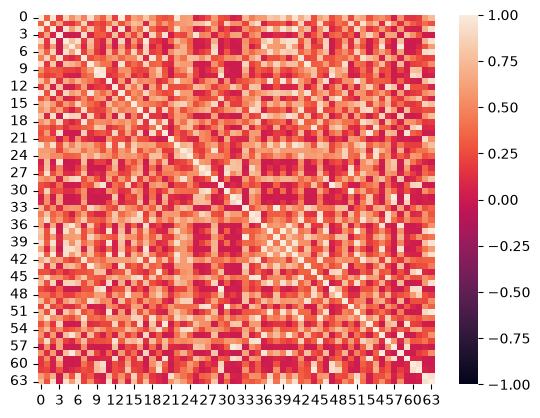

Guardando n_64_dim_2_z_feature_map

Procesando n_72_dim_2_z_feature_map
Procesamiento con matrices precomputadas listo
Confusion matrix: 
 [[4 6]
 [3 5]]

Accuracy = 0.50
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.57      0.40      0.47        10
     Potable       0.45      0.62      0.53         8

    accuracy                           0.50        18
   macro avg       0.51      0.51      0.50        18
weighted avg       0.52      0.50      0.50        18

Real y = [1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1]
Prediction = [0 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 0]


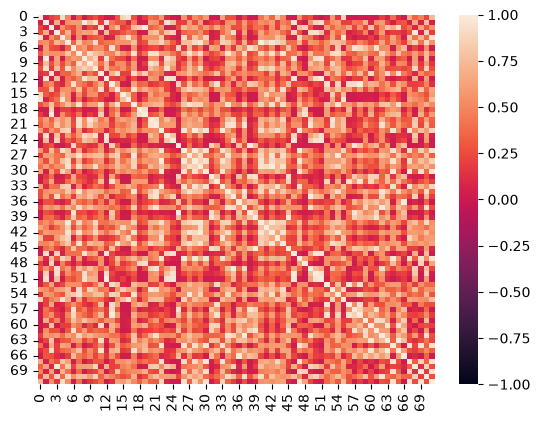

Guardando n_72_dim_2_z_feature_map

Procesando n_32_dim_3_z_feature_map
Procesamiento con matrices precomputadas listo
Confusion matrix: 
 [[3 0]
 [3 2]]

Accuracy = 0.62
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.50      1.00      0.67         3
     Potable       1.00      0.40      0.57         5

    accuracy                           0.62         8
   macro avg       0.75      0.70      0.62         8
weighted avg       0.81      0.62      0.61         8

Real y = [0, 1, 1, 0, 1, 1, 1, 0]
Prediction = [0 0 0 0 1 1 0 0]


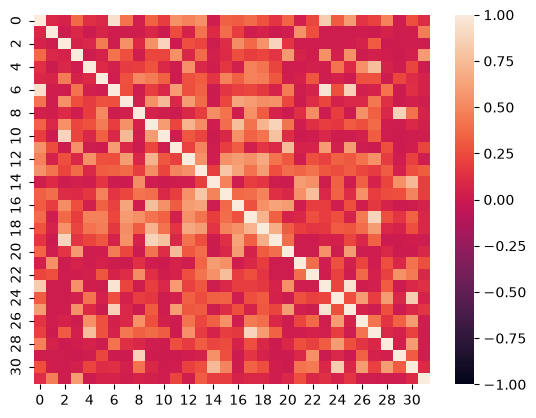

Guardando n_32_dim_3_z_feature_map

Procesando n_40_dim_3_z_feature_map
Procesamiento con matrices precomputadas listo
Confusion matrix: 
 [[3 3]
 [1 3]]

Accuracy = 0.60
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.75      0.50      0.60         6
     Potable       0.50      0.75      0.60         4

    accuracy                           0.60        10
   macro avg       0.62      0.62      0.60        10
weighted avg       0.65      0.60      0.60        10

Real y = [1, 0, 0, 1, 0, 0, 0, 1, 0, 1]
Prediction = [0 0 1 1 1 0 0 1 1 1]


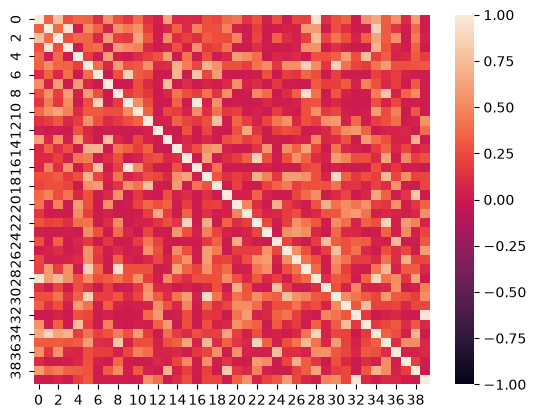

Guardando n_40_dim_3_z_feature_map

Procesando n_48_dim_3_z_feature_map
Procesamiento con matrices precomputadas listo
Confusion matrix: 
 [[4 3]
 [3 2]]

Accuracy = 0.50
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.57      0.57      0.57         7
     Potable       0.40      0.40      0.40         5

    accuracy                           0.50        12
   macro avg       0.49      0.49      0.49        12
weighted avg       0.50      0.50      0.50        12

Real y = [1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1]
Prediction = [0 0 0 0 1 0 0 1 1 1 1 0]


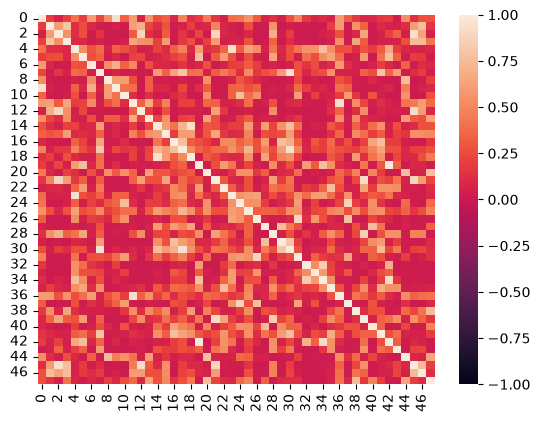

Guardando n_48_dim_3_z_feature_map

Procesando n_56_dim_3_z_feature_map
Procesamiento con matrices precomputadas listo
Confusion matrix: 
 [[4 4]
 [2 4]]

Accuracy = 0.57
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.67      0.50      0.57         8
     Potable       0.50      0.67      0.57         6

    accuracy                           0.57        14
   macro avg       0.58      0.58      0.57        14
weighted avg       0.60      0.57      0.57        14

Real y = [0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1]
Prediction = [0 1 1 0 0 0 0 1 1 1 0 1 1 1]


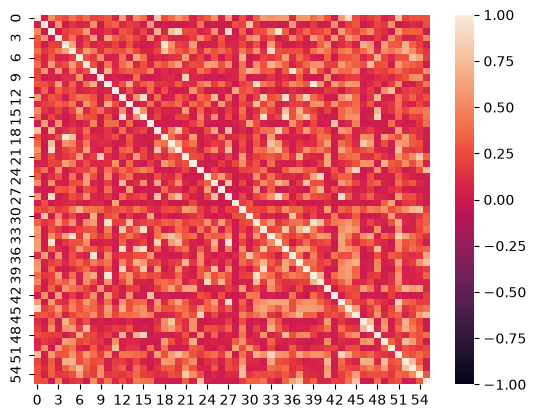

Guardando n_56_dim_3_z_feature_map

Procesando n_64_dim_3_z_feature_map
Procesamiento con matrices precomputadas listo
Confusion matrix: 
 [[4 5]
 [1 6]]

Accuracy = 0.62
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.80      0.44      0.57         9
     Potable       0.55      0.86      0.67         7

    accuracy                           0.62        16
   macro avg       0.67      0.65      0.62        16
weighted avg       0.69      0.62      0.61        16

Real y = [0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0]
Prediction = [1 1 1 0 0 1 1 1 1 1 0 0 1 1 0 1]


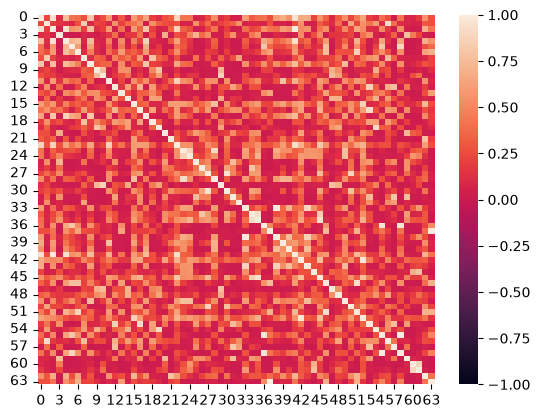

Guardando n_64_dim_3_z_feature_map

Procesando n_72_dim_3_z_feature_map
Procesamiento con matrices precomputadas listo
Confusion matrix: 
 [[6 4]
 [5 3]]

Accuracy = 0.50
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.55      0.60      0.57        10
     Potable       0.43      0.38      0.40         8

    accuracy                           0.50        18
   macro avg       0.49      0.49      0.49        18
weighted avg       0.49      0.50      0.50        18

Real y = [1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1]
Prediction = [0 0 1 0 1 0 1 1 0 0 1 0 0 1 1 0 0 0]


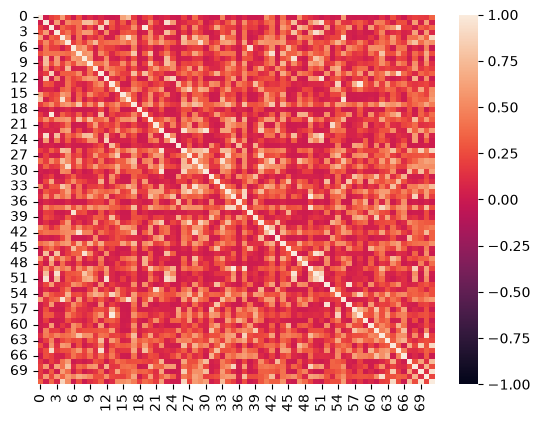

Guardando n_72_dim_3_z_feature_map

Procesando n_32_dim_4_z_feature_map
Procesamiento con matrices precomputadas listo
Confusion matrix: 
 [[3 0]
 [5 0]]

Accuracy = 0.38
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.38      1.00      0.55         3
     Potable       0.00      0.00      0.00         5

    accuracy                           0.38         8
   macro avg       0.19      0.50      0.27         8
weighted avg       0.14      0.38      0.20         8

Real y = [0, 1, 1, 0, 1, 1, 1, 0]
Prediction = [0 0 0 0 0 0 0 0]


/home/jr/.venv/odiseaQ/lib64/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jr/.venv/odiseaQ/lib64/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jr/.venv/odiseaQ/lib64/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

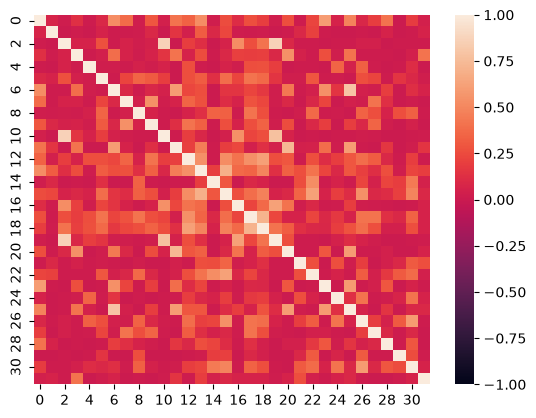

Guardando n_32_dim_4_z_feature_map

Procesando n_40_dim_4_z_feature_map
Procesamiento con matrices precomputadas listo
Confusion matrix: 
 [[3 3]
 [2 2]]

Accuracy = 0.50
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.60      0.50      0.55         6
     Potable       0.40      0.50      0.44         4

    accuracy                           0.50        10
   macro avg       0.50      0.50      0.49        10
weighted avg       0.52      0.50      0.51        10

Real y = [1, 0, 0, 1, 0, 0, 0, 1, 0, 1]
Prediction = [0 0 1 1 1 0 0 0 1 1]


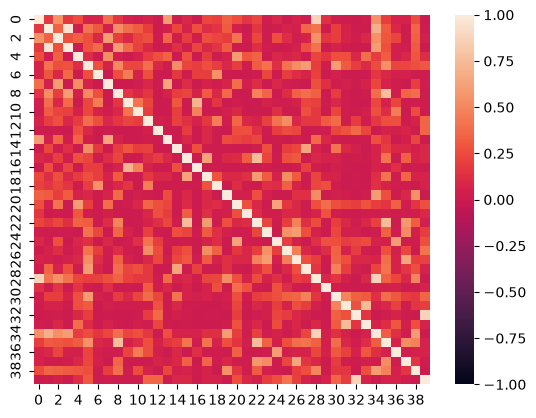

Guardando n_40_dim_4_z_feature_map

Procesando n_48_dim_4_z_feature_map
Procesamiento con matrices precomputadas listo
Confusion matrix: 
 [[3 4]
 [2 3]]

Accuracy = 0.50
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.60      0.43      0.50         7
     Potable       0.43      0.60      0.50         5

    accuracy                           0.50        12
   macro avg       0.51      0.51      0.50        12
weighted avg       0.53      0.50      0.50        12

Real y = [1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1]
Prediction = [1 0 0 0 1 0 1 1 1 1 1 0]


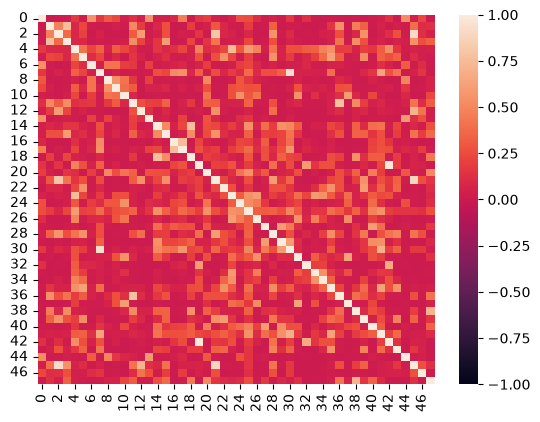

Guardando n_48_dim_4_z_feature_map

Procesando n_56_dim_4_z_feature_map
Procesamiento con matrices precomputadas listo
Confusion matrix: 
 [[4 4]
 [3 3]]

Accuracy = 0.50
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.57      0.50      0.53         8
     Potable       0.43      0.50      0.46         6

    accuracy                           0.50        14
   macro avg       0.50      0.50      0.50        14
weighted avg       0.51      0.50      0.50        14

Real y = [0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1]
Prediction = [0 1 1 1 0 0 0 1 0 1 0 1 0 1]


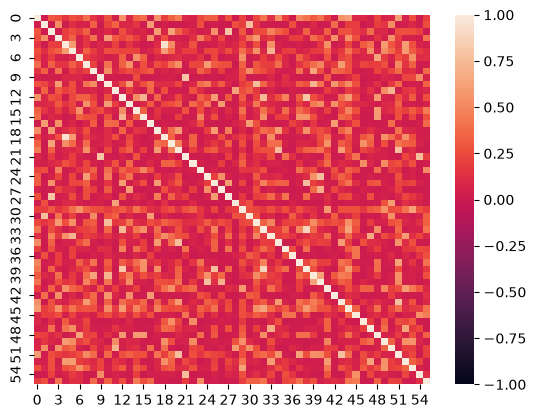

Guardando n_56_dim_4_z_feature_map

Procesando n_64_dim_4_z_feature_map
Procesamiento con matrices precomputadas listo
Confusion matrix: 
 [[4 5]
 [1 6]]

Accuracy = 0.62
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.80      0.44      0.57         9
     Potable       0.55      0.86      0.67         7

    accuracy                           0.62        16
   macro avg       0.67      0.65      0.62        16
weighted avg       0.69      0.62      0.61        16

Real y = [0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0]
Prediction = [0 0 1 1 0 1 1 0 1 1 0 1 1 1 1 1]


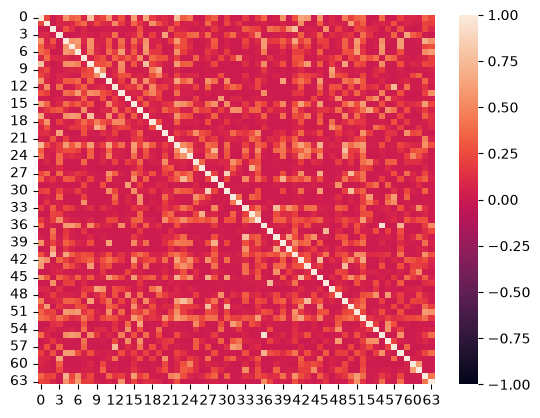

Guardando n_64_dim_4_z_feature_map

Procesando n_72_dim_4_z_feature_map
Procesamiento con matrices precomputadas listo
Confusion matrix: 
 [[7 3]
 [4 4]]

Accuracy = 0.61
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.64      0.70      0.67        10
     Potable       0.57      0.50      0.53         8

    accuracy                           0.61        18
   macro avg       0.60      0.60      0.60        18
weighted avg       0.61      0.61      0.61        18

Real y = [1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1]
Prediction = [0 0 1 0 1 0 1 0 0 0 1 1 0 0 1 1 0 0]


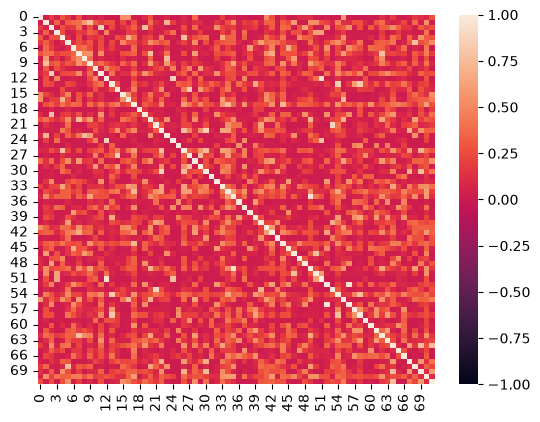

Guardando n_72_dim_4_z_feature_map

Procesando n_32_dim_5_z_feature_map
Procesamiento con matrices precomputadas listo
Confusion matrix: 
 [[3 0]
 [3 2]]

Accuracy = 0.62
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.50      1.00      0.67         3
     Potable       1.00      0.40      0.57         5

    accuracy                           0.62         8
   macro avg       0.75      0.70      0.62         8
weighted avg       0.81      0.62      0.61         8

Real y = [0, 1, 1, 0, 1, 1, 1, 0]
Prediction = [0 0 0 0 1 1 0 0]


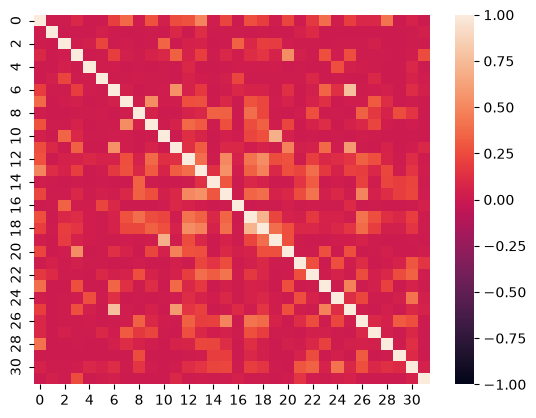

Guardando n_32_dim_5_z_feature_map

Procesando n_40_dim_5_z_feature_map
Procesamiento con matrices precomputadas listo
Confusion matrix: 
 [[1 5]
 [1 3]]

Accuracy = 0.40
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.50      0.17      0.25         6
     Potable       0.38      0.75      0.50         4

    accuracy                           0.40        10
   macro avg       0.44      0.46      0.38        10
weighted avg       0.45      0.40      0.35        10

Real y = [1, 0, 0, 1, 0, 0, 0, 1, 0, 1]
Prediction = [0 0 1 1 1 1 1 1 1 1]


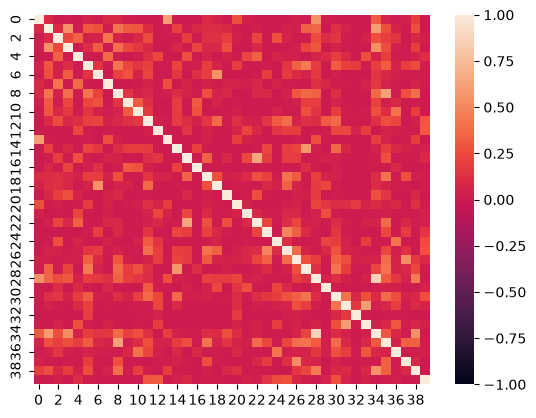

Guardando n_40_dim_5_z_feature_map

Procesando n_48_dim_5_z_feature_map
Procesamiento con matrices precomputadas listo
Confusion matrix: 
 [[1 6]
 [1 4]]

Accuracy = 0.42
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.50      0.14      0.22         7
     Potable       0.40      0.80      0.53         5

    accuracy                           0.42        12
   macro avg       0.45      0.47      0.38        12
weighted avg       0.46      0.42      0.35        12

Real y = [1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1]
Prediction = [1 1 1 1 1 1 0 1 1 1 1 0]


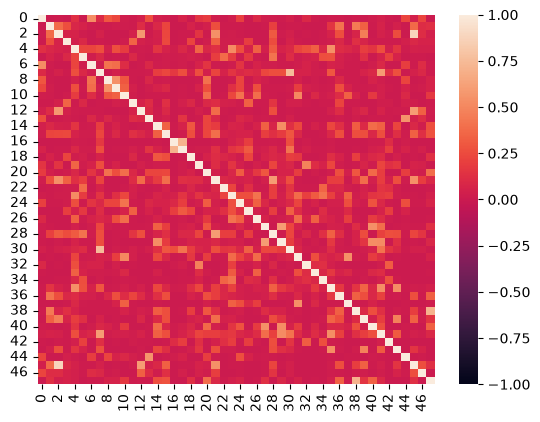

Guardando n_48_dim_5_z_feature_map

Procesando n_56_dim_5_z_feature_map
Procesamiento con matrices precomputadas listo
Confusion matrix: 
 [[4 4]
 [3 3]]

Accuracy = 0.50
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.57      0.50      0.53         8
     Potable       0.43      0.50      0.46         6

    accuracy                           0.50        14
   macro avg       0.50      0.50      0.50        14
weighted avg       0.51      0.50      0.50        14

Real y = [0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1]
Prediction = [0 0 1 0 1 0 0 1 0 1 0 1 1 1]


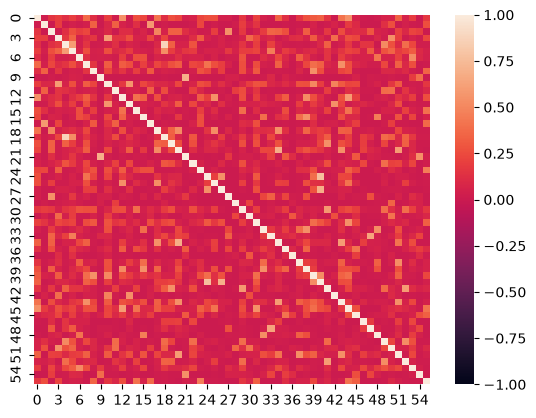

Guardando n_56_dim_5_z_feature_map

Procesando n_64_dim_5_z_feature_map
Procesamiento con matrices precomputadas listo
Confusion matrix: 
 [[6 3]
 [1 6]]

Accuracy = 0.75
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.86      0.67      0.75         9
     Potable       0.67      0.86      0.75         7

    accuracy                           0.75        16
   macro avg       0.76      0.76      0.75        16
weighted avg       0.77      0.75      0.75        16

Real y = [0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0]
Prediction = [0 1 1 0 0 0 1 1 1 1 0 0 1 1 1 0]


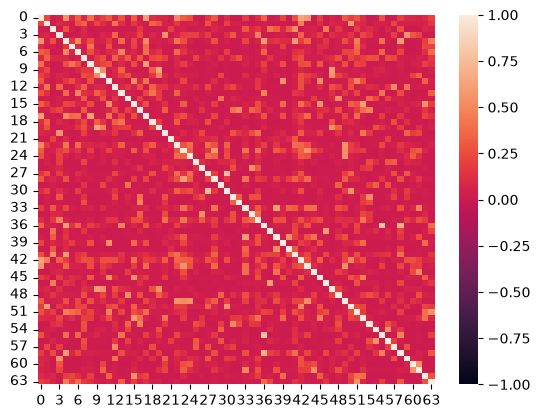

Guardando n_64_dim_5_z_feature_map

Procesando n_72_dim_5_z_feature_map
Procesamiento con matrices precomputadas listo
Confusion matrix: 
 [[5 5]
 [4 4]]

Accuracy = 0.50
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.56      0.50      0.53        10
     Potable       0.44      0.50      0.47         8

    accuracy                           0.50        18
   macro avg       0.50      0.50      0.50        18
weighted avg       0.51      0.50      0.50        18

Real y = [1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1]
Prediction = [1 0 1 1 1 1 1 0 0 0 1 0 0 1 1 0 0 0]


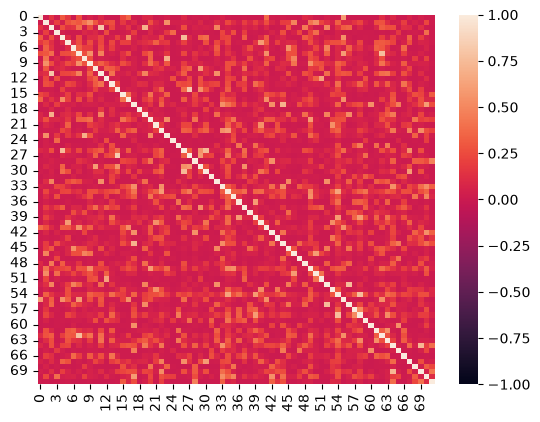

Guardando n_72_dim_5_z_feature_map

Procesando n_32_dim_6_z_feature_map
Procesamiento con matrices precomputadas listo
Confusion matrix: 
 [[3 0]
 [4 1]]

Accuracy = 0.50
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.43      1.00      0.60         3
     Potable       1.00      0.20      0.33         5

    accuracy                           0.50         8
   macro avg       0.71      0.60      0.47         8
weighted avg       0.79      0.50      0.43         8

Real y = [0, 1, 1, 0, 1, 1, 1, 0]
Prediction = [0 0 0 0 1 0 0 0]


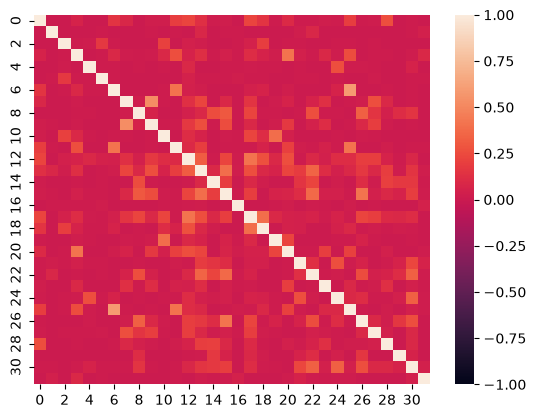

Guardando n_32_dim_6_z_feature_map

Procesando n_40_dim_6_z_feature_map
Procesamiento con matrices precomputadas listo
Confusion matrix: 
 [[0 6]
 [1 3]]

Accuracy = 0.30
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.00      0.00      0.00         6
     Potable       0.33      0.75      0.46         4

    accuracy                           0.30        10
   macro avg       0.17      0.38      0.23        10
weighted avg       0.13      0.30      0.18        10

Real y = [1, 0, 0, 1, 0, 0, 0, 1, 0, 1]
Prediction = [0 1 1 1 1 1 1 1 1 1]


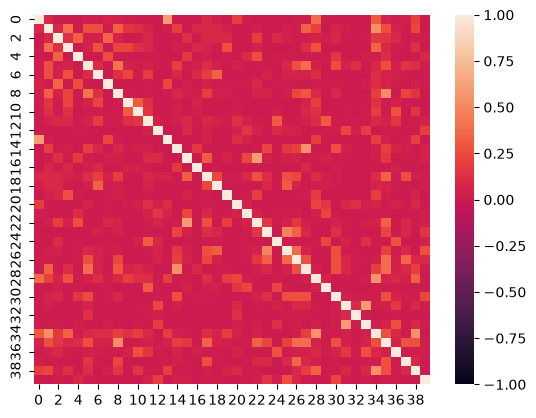

Guardando n_40_dim_6_z_feature_map

Procesando n_48_dim_6_z_feature_map
Procesamiento con matrices precomputadas listo
Confusion matrix: 
 [[2 5]
 [1 4]]

Accuracy = 0.50
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.67      0.29      0.40         7
     Potable       0.44      0.80      0.57         5

    accuracy                           0.50        12
   macro avg       0.56      0.54      0.49        12
weighted avg       0.57      0.50      0.47        12

Real y = [1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1]
Prediction = [1 1 1 1 1 1 0 1 0 1 1 0]


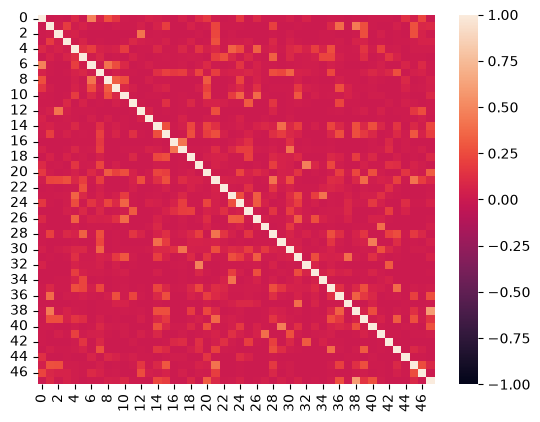

Guardando n_48_dim_6_z_feature_map

Procesando n_56_dim_6_z_feature_map
Procesamiento con matrices precomputadas listo
Confusion matrix: 
 [[6 2]
 [2 4]]

Accuracy = 0.71
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.75      0.75      0.75         8
     Potable       0.67      0.67      0.67         6

    accuracy                           0.71        14
   macro avg       0.71      0.71      0.71        14
weighted avg       0.71      0.71      0.71        14

Real y = [0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1]
Prediction = [0 0 1 0 1 0 0 1 1 0 0 1 0 1]


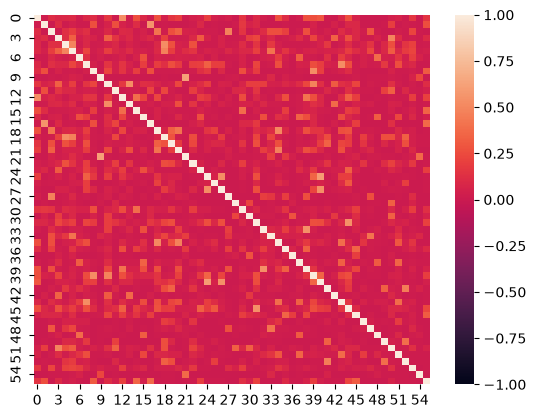

Guardando n_56_dim_6_z_feature_map

Procesando n_64_dim_6_z_feature_map
Procesamiento con matrices precomputadas listo
Confusion matrix: 
 [[7 2]
 [3 4]]

Accuracy = 0.69
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.70      0.78      0.74         9
     Potable       0.67      0.57      0.62         7

    accuracy                           0.69        16
   macro avg       0.68      0.67      0.68        16
weighted avg       0.69      0.69      0.68        16

Real y = [0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0]
Prediction = [0 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0]


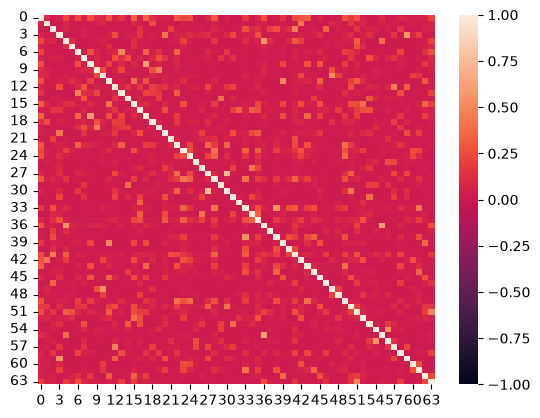

Guardando n_64_dim_6_z_feature_map

Procesando n_72_dim_6_z_feature_map
Procesamiento con matrices precomputadas listo
Confusion matrix: 
 [[6 4]
 [4 4]]

Accuracy = 0.56
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.60      0.60      0.60        10
     Potable       0.50      0.50      0.50         8

    accuracy                           0.56        18
   macro avg       0.55      0.55      0.55        18
weighted avg       0.56      0.56      0.56        18

Real y = [1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1]
Prediction = [0 0 1 1 1 0 1 0 0 0 1 0 0 1 1 1 0 0]


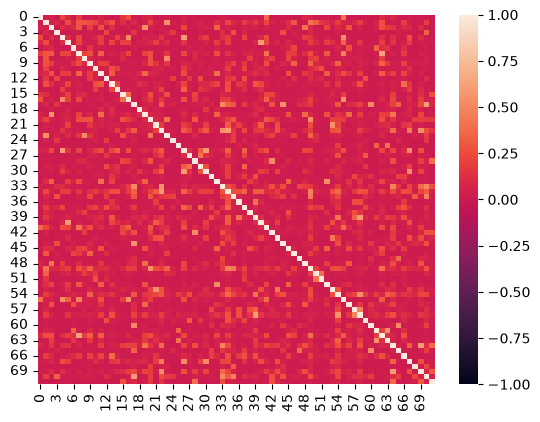

Guardando n_72_dim_6_z_feature_map

Procesando n_32_dim_7_z_feature_map
Procesamiento con matrices precomputadas listo
Confusion matrix: 
 [[2 1]
 [4 1]]

Accuracy = 0.38
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.33      0.67      0.44         3
     Potable       0.50      0.20      0.29         5

    accuracy                           0.38         8
   macro avg       0.42      0.43      0.37         8
weighted avg       0.44      0.38      0.35         8

Real y = [0, 1, 1, 0, 1, 1, 1, 0]
Prediction = [1 0 0 0 1 0 0 0]


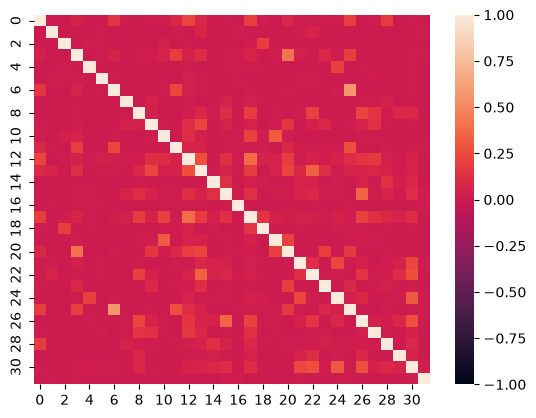

Guardando n_32_dim_7_z_feature_map

Procesando n_40_dim_7_z_feature_map
Procesamiento con matrices precomputadas listo
Confusion matrix: 
 [[1 5]
 [1 3]]

Accuracy = 0.40
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.50      0.17      0.25         6
     Potable       0.38      0.75      0.50         4

    accuracy                           0.40        10
   macro avg       0.44      0.46      0.38        10
weighted avg       0.45      0.40      0.35        10

Real y = [1, 0, 0, 1, 0, 0, 0, 1, 0, 1]
Prediction = [0 1 1 1 1 0 1 1 1 1]


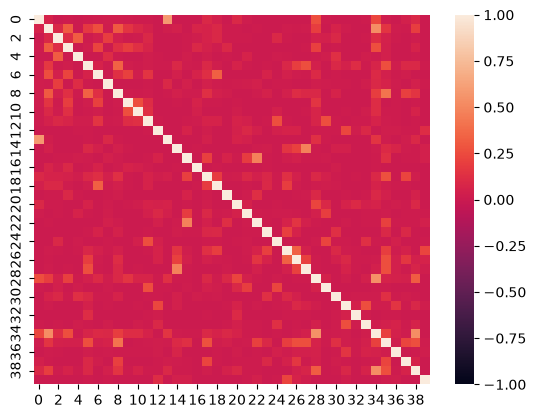

Guardando n_40_dim_7_z_feature_map

Procesando n_48_dim_7_z_feature_map
Procesamiento con matrices precomputadas listo
Confusion matrix: 
 [[2 5]
 [1 4]]

Accuracy = 0.50
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.67      0.29      0.40         7
     Potable       0.44      0.80      0.57         5

    accuracy                           0.50        12
   macro avg       0.56      0.54      0.49        12
weighted avg       0.57      0.50      0.47        12

Real y = [1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1]
Prediction = [1 1 1 1 1 1 0 1 1 1 0 0]


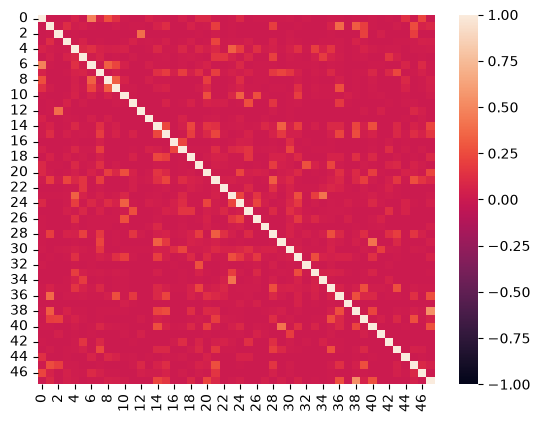

Guardando n_48_dim_7_z_feature_map

Procesando n_56_dim_7_z_feature_map
Procesamiento con matrices precomputadas listo
Confusion matrix: 
 [[5 3]
 [2 4]]

Accuracy = 0.64
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.71      0.62      0.67         8
     Potable       0.57      0.67      0.62         6

    accuracy                           0.64        14
   macro avg       0.64      0.65      0.64        14
weighted avg       0.65      0.64      0.64        14

Real y = [0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1]
Prediction = [0 1 1 0 1 0 0 1 0 1 0 1 0 1]


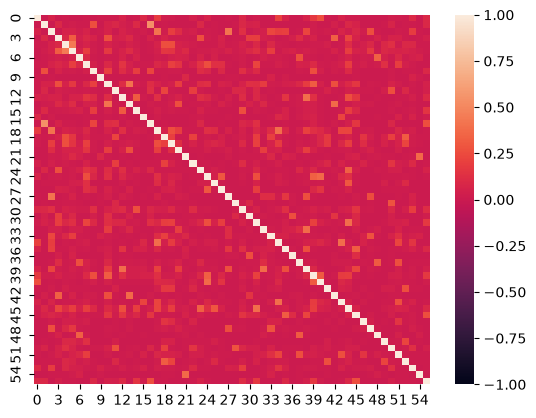

Guardando n_56_dim_7_z_feature_map

Procesando n_64_dim_7_z_feature_map
Procesamiento con matrices precomputadas listo
Confusion matrix: 
 [[1 8]
 [3 4]]

Accuracy = 0.31
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.25      0.11      0.15         9
     Potable       0.33      0.57      0.42         7

    accuracy                           0.31        16
   macro avg       0.29      0.34      0.29        16
weighted avg       0.29      0.31      0.27        16

Real y = [0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0]
Prediction = [1 1 0 1 0 0 1 1 1 1 1 1 0 1 1 1]


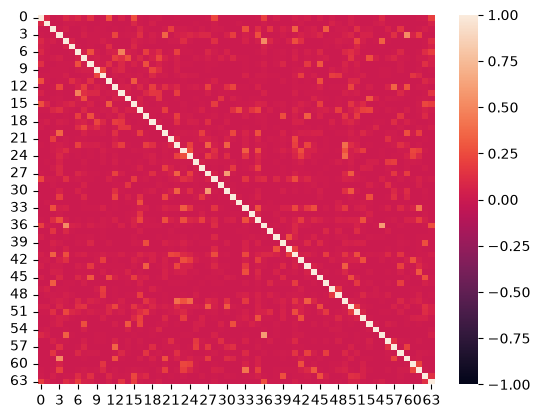

Guardando n_64_dim_7_z_feature_map

Procesando n_72_dim_7_z_feature_map
Procesamiento con matrices precomputadas listo
Confusion matrix: 
 [[6 4]
 [3 5]]

Accuracy = 0.61
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.67      0.60      0.63        10
     Potable       0.56      0.62      0.59         8

    accuracy                           0.61        18
   macro avg       0.61      0.61      0.61        18
weighted avg       0.62      0.61      0.61        18

Real y = [1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1]
Prediction = [0 0 1 0 1 0 1 1 0 0 1 1 0 1 1 1 0 0]


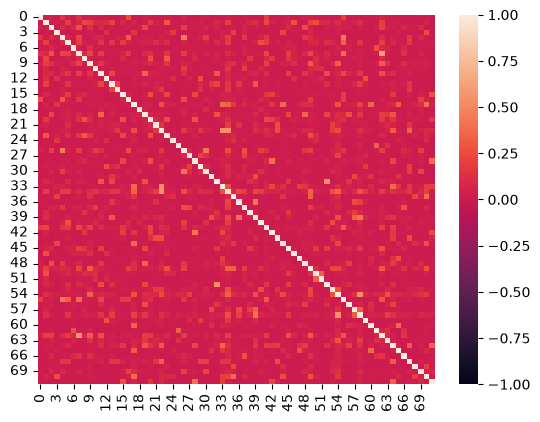

Guardando n_72_dim_7_z_feature_map

Procesando n_32_dim_8_z_feature_map
Procesamiento con matrices precomputadas listo
Confusion matrix: 
 [[3 0]
 [4 1]]

Accuracy = 0.50
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.43      1.00      0.60         3
     Potable       1.00      0.20      0.33         5

    accuracy                           0.50         8
   macro avg       0.71      0.60      0.47         8
weighted avg       0.79      0.50      0.43         8

Real y = [0, 1, 1, 0, 1, 1, 1, 0]
Prediction = [0 0 0 0 1 0 0 0]


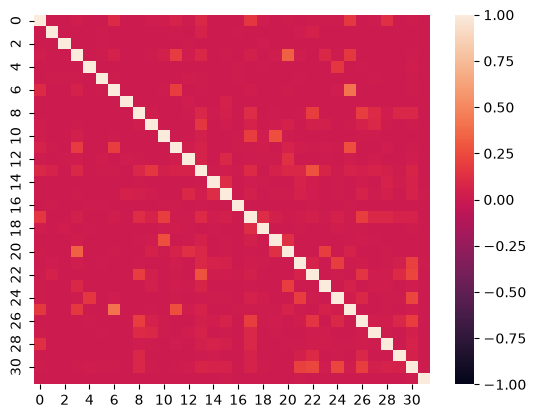

Guardando n_32_dim_8_z_feature_map

Procesando n_40_dim_8_z_feature_map
Procesamiento con matrices precomputadas listo
Confusion matrix: 
 [[2 4]
 [1 3]]

Accuracy = 0.50
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.67      0.33      0.44         6
     Potable       0.43      0.75      0.55         4

    accuracy                           0.50        10
   macro avg       0.55      0.54      0.49        10
weighted avg       0.57      0.50      0.48        10

Real y = [1, 0, 0, 1, 0, 0, 0, 1, 0, 1]
Prediction = [0 1 1 1 1 0 0 1 1 1]


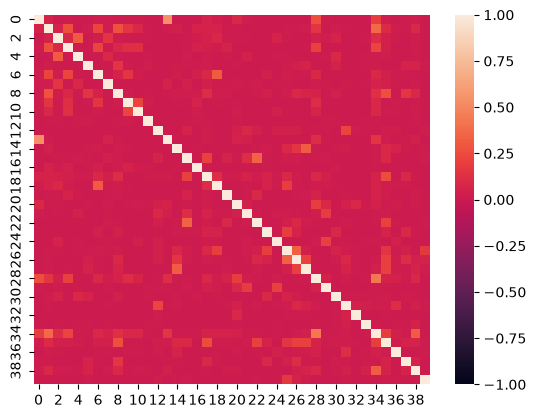

Guardando n_40_dim_8_z_feature_map

Procesando n_48_dim_8_z_feature_map
Procesamiento con matrices precomputadas listo
Confusion matrix: 
 [[2 5]
 [4 1]]

Accuracy = 0.25
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.33      0.29      0.31         7
     Potable       0.17      0.20      0.18         5

    accuracy                           0.25        12
   macro avg       0.25      0.24      0.24        12
weighted avg       0.26      0.25      0.26        12

Real y = [1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1]
Prediction = [0 1 1 1 0 0 1 1 0 1 0 0]


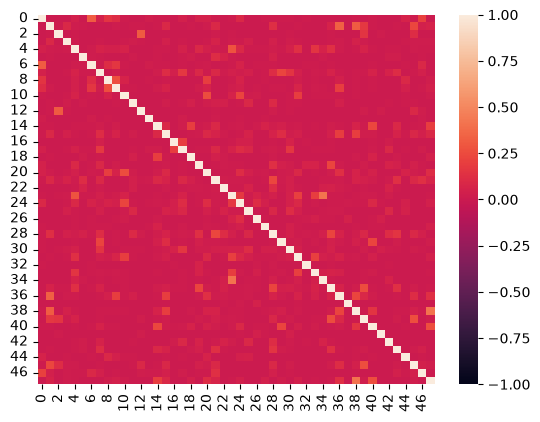

Guardando n_48_dim_8_z_feature_map

Procesando n_56_dim_8_z_feature_map
Procesamiento con matrices precomputadas listo
Confusion matrix: 
 [[3 5]
 [2 4]]

Accuracy = 0.50
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.60      0.38      0.46         8
     Potable       0.44      0.67      0.53         6

    accuracy                           0.50        14
   macro avg       0.52      0.52      0.50        14
weighted avg       0.53      0.50      0.49        14

Real y = [0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1]
Prediction = [0 1 1 0 1 1 0 1 0 1 0 1 1 1]


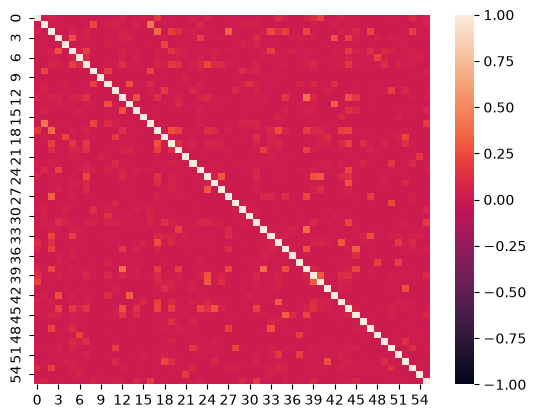

Guardando n_56_dim_8_z_feature_map

Procesando n_64_dim_8_z_feature_map
Procesamiento con matrices precomputadas listo
Confusion matrix: 
 [[1 8]
 [3 4]]

Accuracy = 0.31
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.25      0.11      0.15         9
     Potable       0.33      0.57      0.42         7

    accuracy                           0.31        16
   macro avg       0.29      0.34      0.29        16
weighted avg       0.29      0.31      0.27        16

Real y = [0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0]
Prediction = [1 1 0 1 0 0 1 1 1 1 1 1 0 1 1 1]


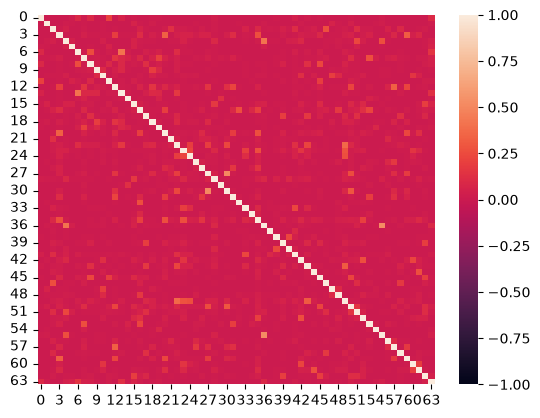

Guardando n_64_dim_8_z_feature_map

Procesando n_72_dim_8_z_feature_map


KeyboardInterrupt: 

In [99]:
for fm in FEATURE_MAPS:
    for dim in PCA_DIMENTIONS:
        for n in NUM_MUESTRAS_ENTRENAMIENTO:
            
            path = '_'.join(['n', f'{n}', 'dim', f'{dim}', f'{fm.__name__}'])

            print(f'Procesando {path}')
            
            qsvm.getData(n)
            qsvm.proccess_data(dim)

            if USAR_MATRICES_PRECOMPUTADAS == True:

                k_path = os.path.join('..', 'data', 'kernel', f'{path}.csv')
                test_path = os.path.join('..', 'data', 'test', f'{path}.csv')

                try:
                    
                    qsvm.q_kernel = read_csv(k_path)
                    qsvm.q_kernel = qsvm.q_kernel.drop('Unnamed: 0', axis = 1)
                    qsvm.q_x_test = read_csv(test_path)
                    qsvm.q_x_test = qsvm.q_x_test.drop('Unnamed: 0', axis = 1)

                    qsvm.qsvm.fit(qsvm.q_kernel, qsvm.y_train)

                    print('Procesamiento con matrices precomputadas listo')
                    
                except FileNotFoundError:
                    
                    qsvm.getData(n)
                    qsvm.proccess_data(dim)
                    qsvm.generar_qsmv(fm)

                    print('Matrices precomputadas no encontradas')

            else:

                
                
                
                qsvm.generar_qsmv(fm)

                print('Kernel generado')

            qsvm.test()
                    
            heatmap(qsvm.q_kernel, vmax=1, vmin=-1)
            plt.show()
            
            qsvm.guardar(path)